# The Challenge of Scaling Production

Have questions? Email James.Lehner@gmail.com or QualityIsBroken@gmail.com

In [152]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

%matplotlib inline

## Figure 1. Square loss function

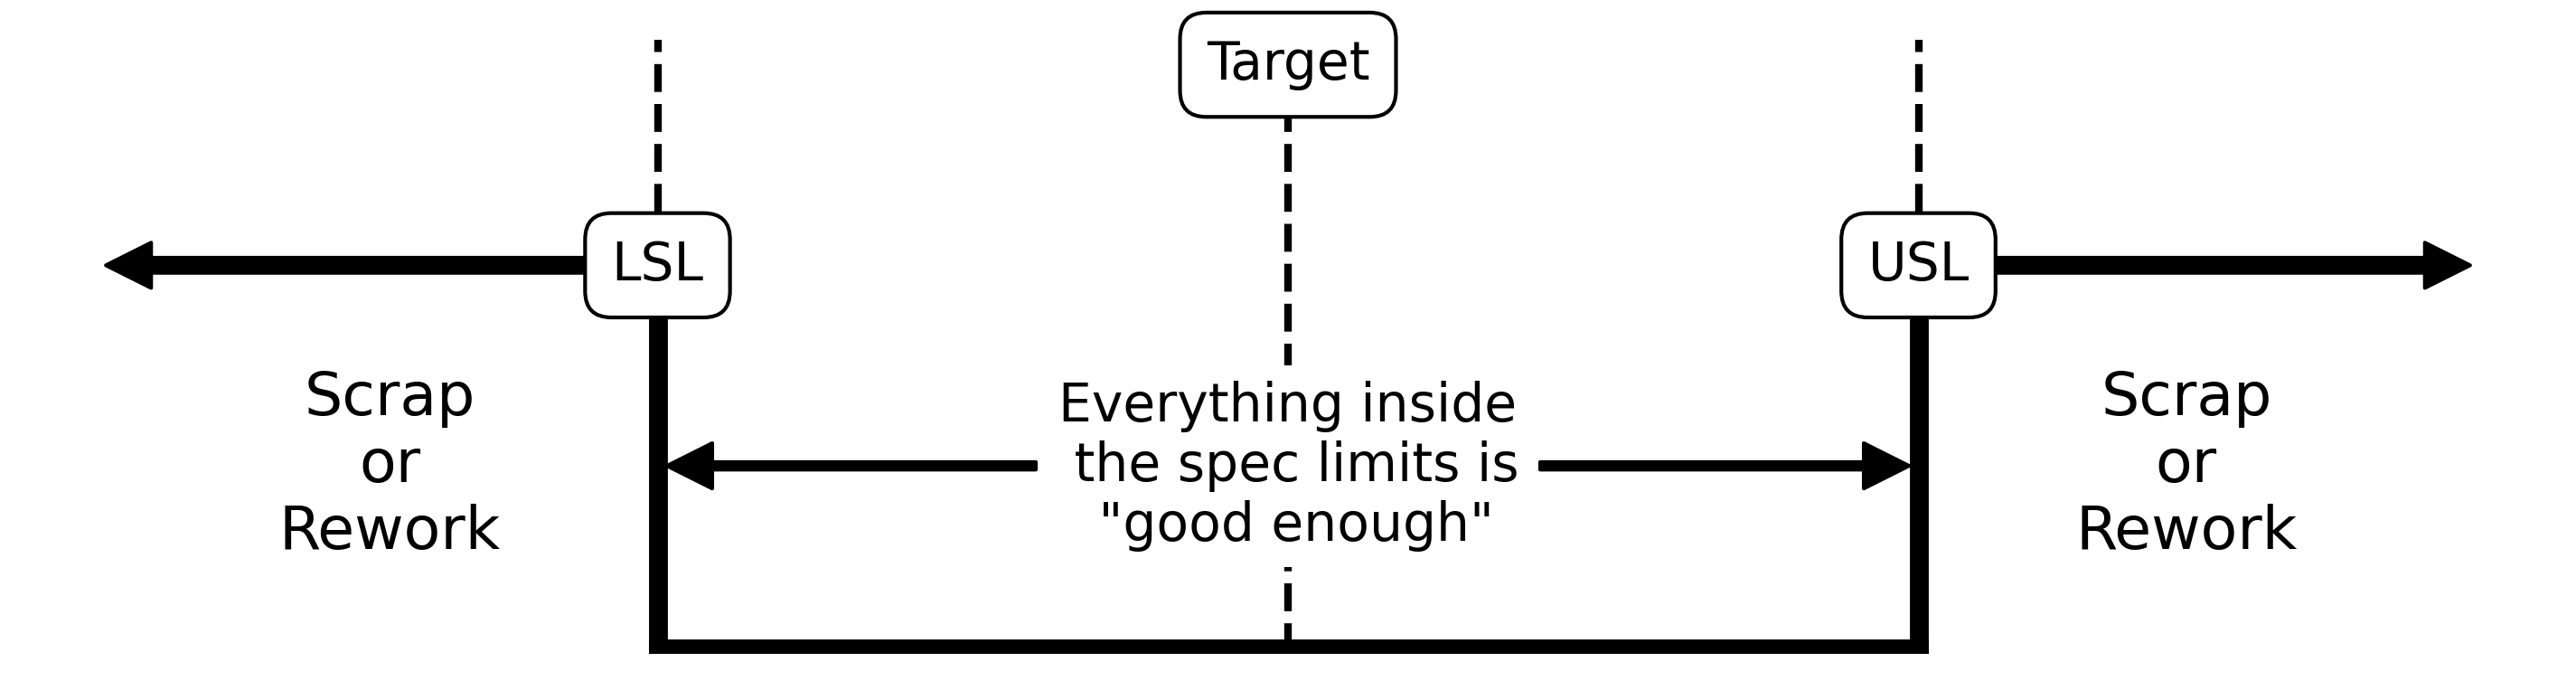

In [257]:
# Create fig and ax
fig, ax = plt.subplots(figsize=(12, 3), dpi=300)

# Specification limits (LSL, USL, Target)
spec_limits = [-2, 0, 2]
for x in spec_limits:
    ax.axvline(x, ls='--', lw=2, color='black', ymin=0.005, ymax=0.9 if x == 0 else 0.98)

# Outside limit horizontal arrows
for x_start, x_end in [(-3.75, -2), (3.75, 2)]:
    ax.annotate('', xy=(x_start, 0.31), xytext=(x_end, 0.31),
                arrowprops=dict(edgecolor='black', facecolor='black'))

# Text labels for limits
labels = { -2: "LSL", 2: "USL", 0: "Target"}
for x, label in labels.items():
    ax.text(x, 0.31 if x else 0.47, label, ha='center', va='center', fontsize=14,
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round', pad=0.5))

# Define annotations (text, xy-coordinates)
annotations = [
    ('Scrap\nor\nRework', (-2.85, 0.15)),
    ('Scrap\nor\nRework', (2.85, 0.15))
]

# Add annotations
for text, xy in annotations:
    ax.annotate(text, 
                xy=xy,
                ha='center', 
                va='center', 
                fontsize=16)
    
ax.annotate('Everything inside\n the spec limits is\n "good enough"',
            xy=(-1.95, 0.15),
            xytext=(0, 0.15),
            ha='center', va='center', fontsize=14,
            bbox=dict(facecolor='white', edgecolor='none', alpha=1))

# Arrows for inside the limits
for x_start, x_end in [(-1.97, -0.8), (1.97, 0.8)]:
    ax.annotate('', xy=(x_start, 0.15), xytext=(x_end, 0.15),
                arrowprops=dict(edgecolor='black', facecolor='black', width=2))

# Thick boundary lines at LSL and USL
for x in [-2, 2]:
    ax.axvline(x, ls='-', lw=5, color='black', ymax=0.62)

# Horizontal line connecting spec limits
ax.axhline(0.004, ls='-', lw=5, color='black', xmin=0.25, xmax=0.75)

# Remove top and right spines
sns.despine()
# Set alpha for left and bottom spines
ax.spines[['left', 'bottom']].set_alpha(0.5)

# Set axis limits
ax.set_xlim([-4, 4])
ax.set_ylim([0, 0.5])

# Remove axes
ax.set_axis_off()

# Show plot
plt.show()

## Figure 2. Unknown unknowns as a function of volume

In [224]:
# Establish initial conditions
a = 100 # Initial value
b = 1.75 # Groth factor
n = 10

# Calculate unknown unknowns using exponential growth function: f(x) = A*B^i
values = [round(a * b**i, 2) for i in range(n)]

# Create dataframe
df = pd.DataFrame()
df['Unknown Unknowns'] = pd.Series(values)
df['Volume of Product'] = pd.Series([i for i in range(1, n+1)])

# Show dataframe
df

,Unknown Unknowns,Volume of Product
0,100.00,1
1,175.00,2
2,306.25,3
3,535.94,4
4,937.89,5
5,1641.31,6
6,2872.29,7
7,5026.51,8
8,8796.39,9
9,15393.68,10


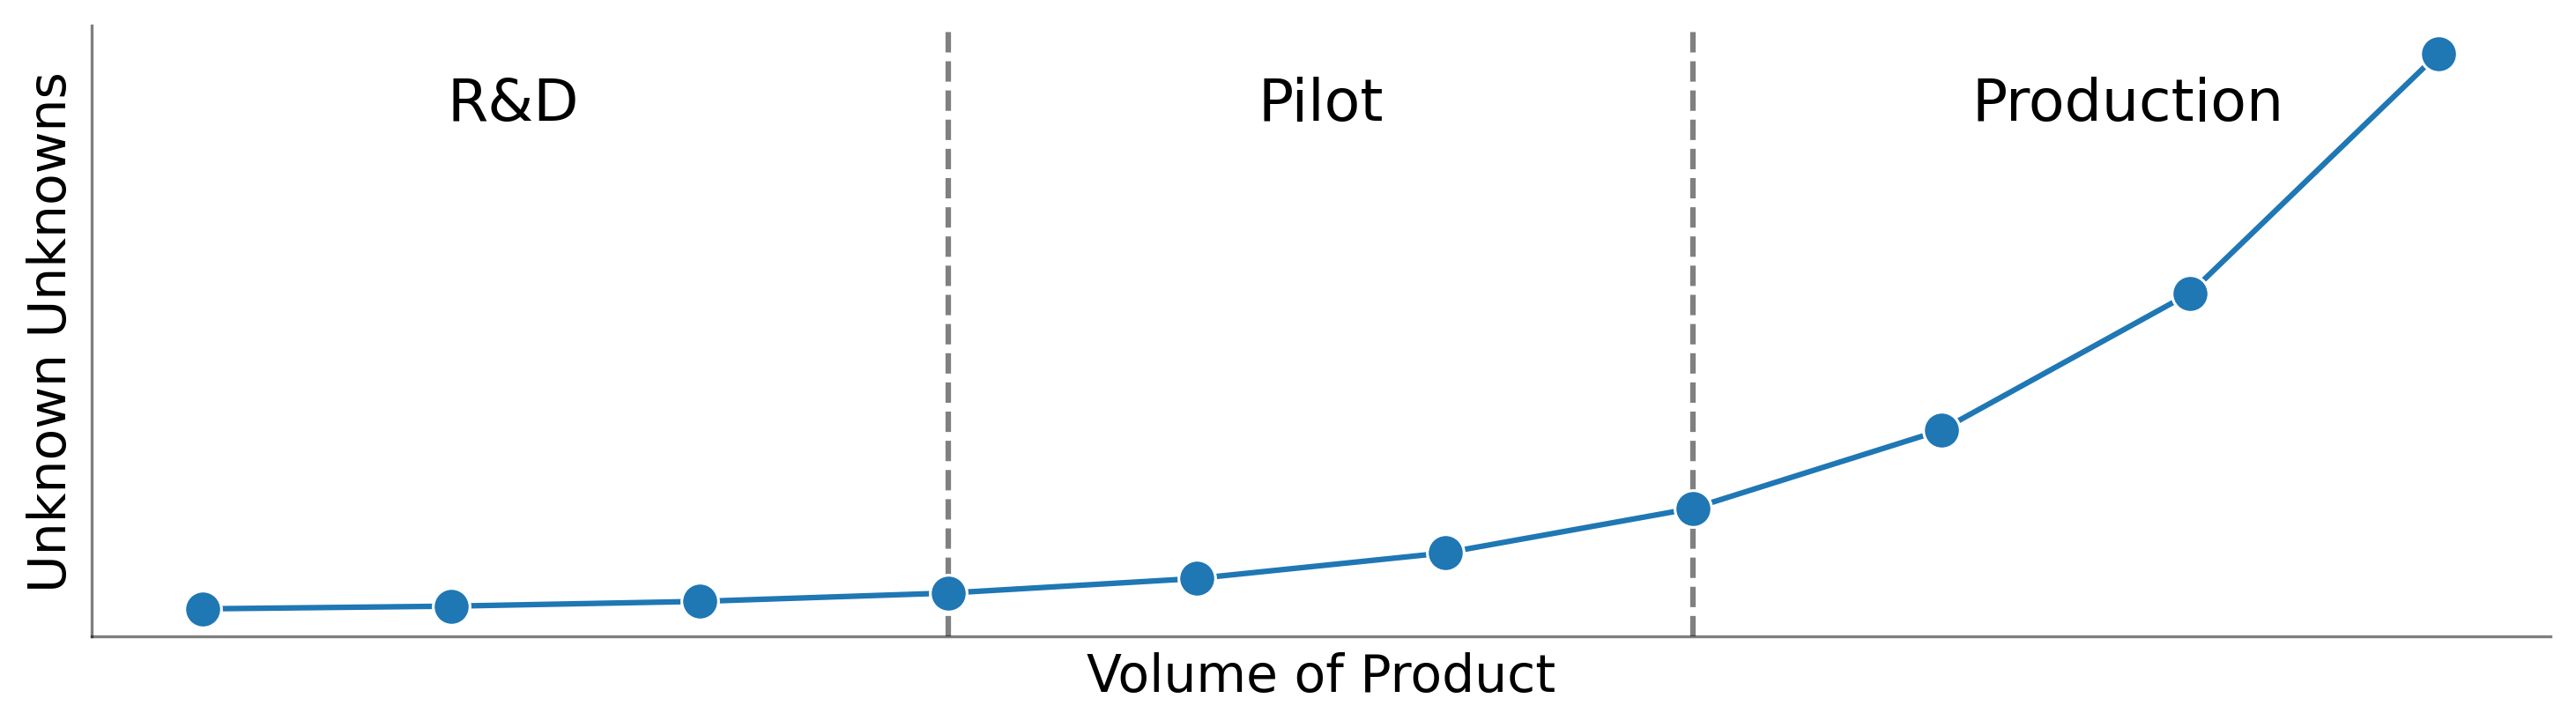

In [225]:
# Create fig and ax
fig, ax = plt.subplots(figsize=(12,3), dpi=300)

# Plot data
sns.lineplot(df, 
             x='Volume of Product', 
             y='Unknown Unknowns', 
             marker='o', 
             markersize=10,
             ax=ax)

# Plot vertical lines
for i in [4,7]:
    ax.axvline(i, ls='--', c='gray', zorder=0)

# Define annotations (text, xy-coordinates, xytext-coordinates)
annotations = [
    ('R&D', (2.25, 14000)),
    ('Pilot', (5.5, 14000)),
     ('Production', (8.75, 14000))
]

# Add annotations using a loop
for text, xy in annotations:
    ax.annotate(text, 
                xy=xy,
                ha='center', 
                va='center', 
                fontsize=16)

# Set spine visibility and alpha
sns.despine()
ax.spines[['left','bottom']].set_alpha(0.5)

# Remove tick marks and labels
ax.set_yticks([])
ax.set_xticks([])

# Axis labels
ax.set_ylabel('Unknown Unknowns',fontsize=14)
ax.set_xlabel('Volume of Product',fontsize=14)

plt.show()

## Figure 3. Taguchi loss function

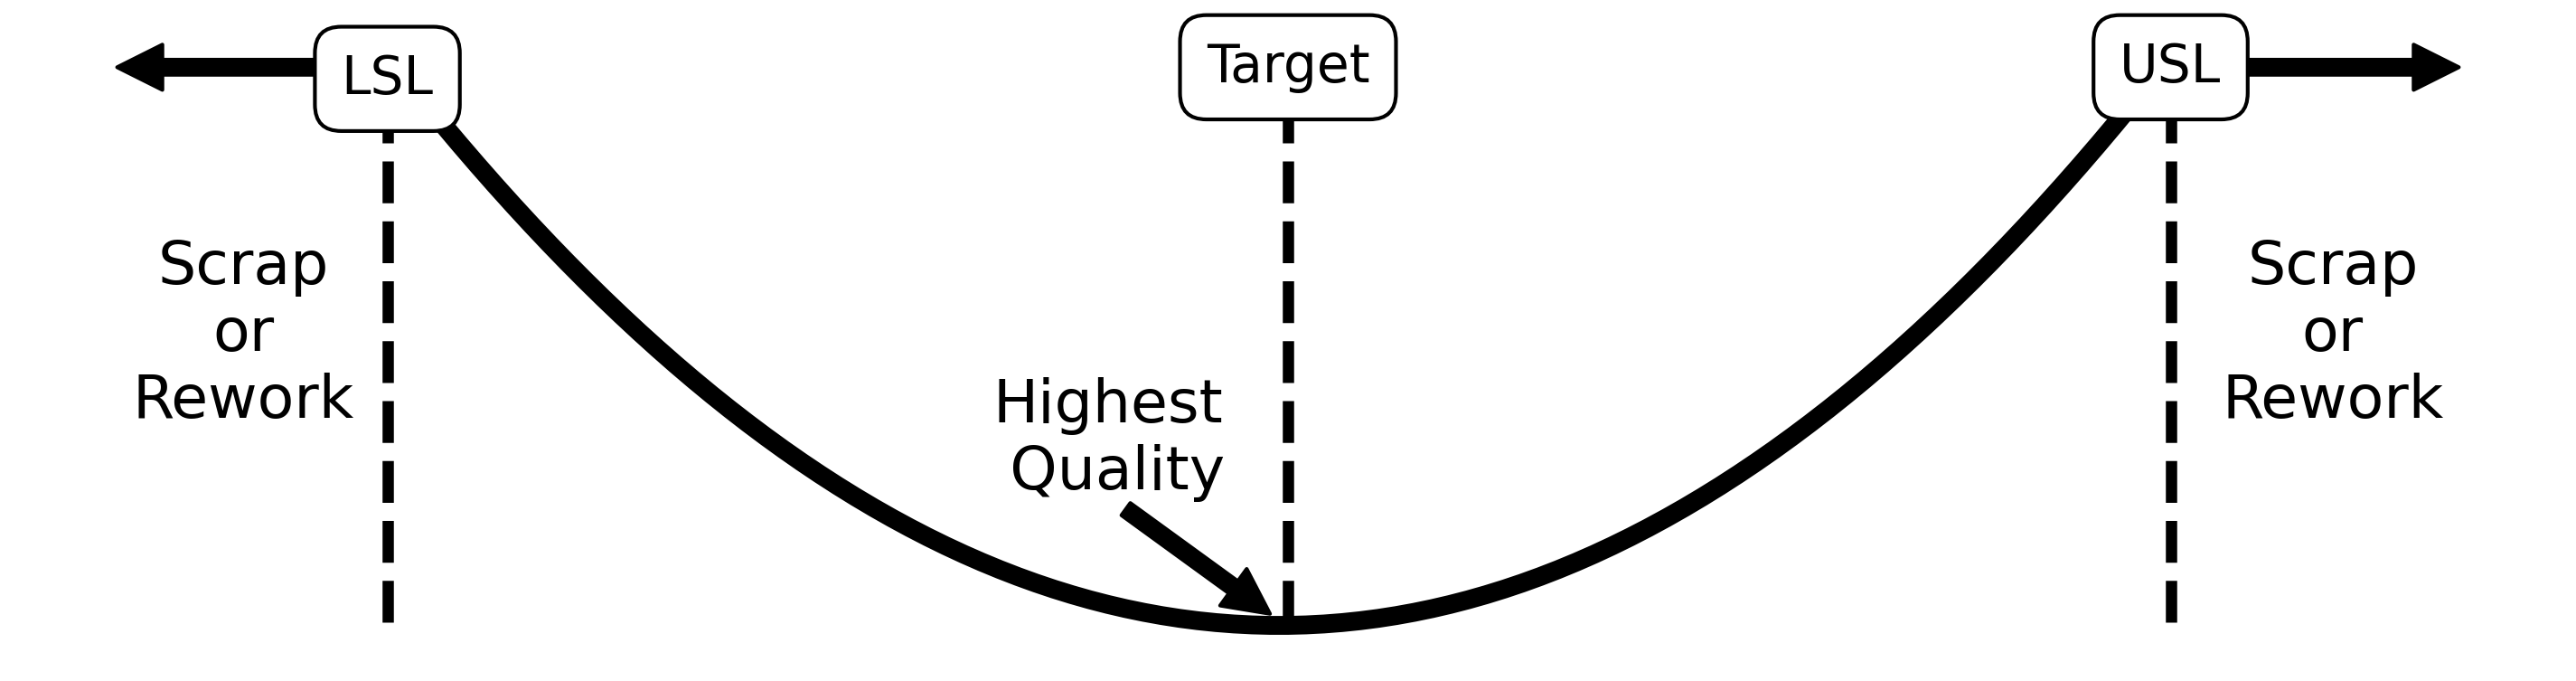

In [244]:
# Specify parabola
x = np.linspace(-0.7, 0.7, 100)
y = x**2

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 3), dpi=300)

# Plot parabola
ax.plot(y, ls='-', lw=5, color='black')

# Specification limits (LSL, Target, USL)
spec_limits = [0, 50, 99]
ymax_values = [0.95, 0.90, 0.95]  # Different ymax for each line

for x_val, ymax in zip(spec_limits, ymax_values):
    ax.axvline(x_val, ls='--', lw=3, color='black', ymin=0.05, ymax=ymax)

# Outside limit horizontal arrows
arrow_positions = [(-15, 0.48, 0, 0.48), (115, 0.48, 100, 0.48)]
for x_start, y_start, x_end, y_end in arrow_positions:
    ax.annotate('', xy=(x_start, y_start), xytext=(x_end, y_end),
                arrowprops=dict(edgecolor='black', facecolor='black'))

# Text labels for LSL, USL, and Target
labels = {0: "LSL", 99: "USL", 50: "Target"}

for x_val, label in labels.items():
    ax.text(x_val, 0.48 if x_val else 0.47, label, ha='center', va='center', fontsize=14,
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round', pad=0.5))

# Define annotations (text, xy-coordinates)
annotations = [
    ('Scrap\nor\nRework', (-8, 0.25)),
    ('Scrap\nor\nRework', (108, 0.25)),
     ('Highest\n Quality', (40, 0.16))
]

# Add annotations
for text, xy in annotations:
    ax.annotate(text, 
                xy=xy,
                ha='center', 
                va='center', 
                fontsize=16)

# Arrow pointing towards "Highest Quality"
ax.annotate('', xy=(49, 0.01), xytext=(41, 0.1),
            arrowprops=dict(edgecolor='black', facecolor='black'))

# Remove axis visibility
ax.set_axis_off()

# Set x-axis limits
ax.set_xlim([-20, 120])

# Remove upper and right spines
sns.despine()
# Set alpha for bottom and left
ax.spines[['left','bottom']].set_alpha(0.5)

# Show plot
plt.show()